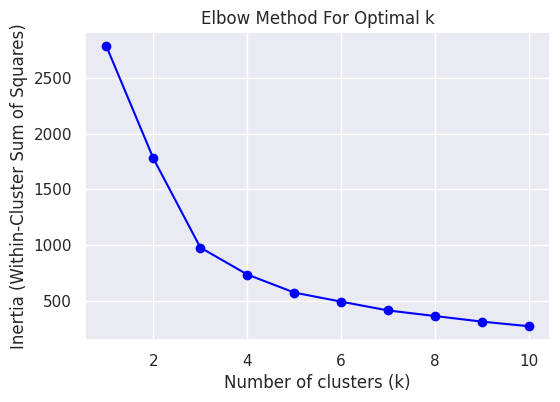

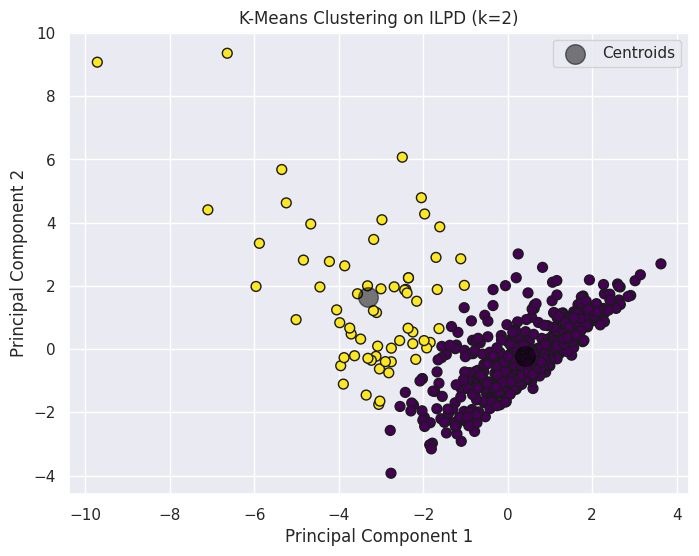

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Plot styling to match lab notebook
sns.set()

# 1. Load Data
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv").dropna()

# Label Encode Gender
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

# 2. Drop target variable for Unsupervised Learning
X = df.drop('Selector', axis=1)

# 3. Scale the data (Crucial for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Reduce to 2D using PCA for visualization (to match 2D scatter plots in lab)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Find optimal K using the Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.show()

# 6. Fit KMeans (Choosing k=2 based on dataset nature/elbow)
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_pca)

# 7. Visualize Clusters and Centroids
plt.figure(figsize=(8, 6))

# Plot the points (colored by cluster label)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, s=50, cmap='viridis', edgecolor='k')

# Plot the cluster centers (Black circles)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, label='Centroids')

plt.title(f'K-Means Clustering on ILPD (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

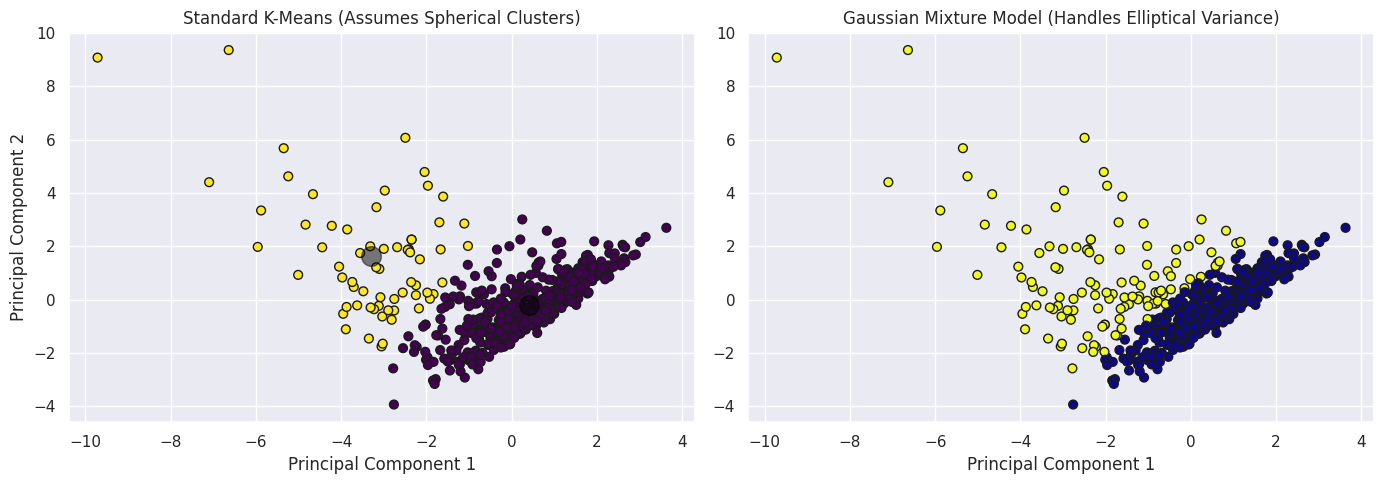

GMM Prediction Probabilities for first 5 patients (Cluster 0 vs Cluster 1):
[[0.959 0.041]
 [0.    1.   ]
 [0.006 0.994]
 [0.982 0.018]
 [0.853 0.147]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Plot styling to match lab notebook
sns.set()

# 1. Load and Preprocess Data
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv").dropna()
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
X = df.drop('Selector', axis=1)

# Scale data
X_scaled = StandardScaler().fit_transform(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Set number of clusters (Liver Patient vs. Non-Patient)
n_clusters = 2

# 2. Fit K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

# 3. Fit Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

# 4. Plotting Comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot K-Means
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=40, cmap='viridis', edgecolor='k')
centers = kmeans.cluster_centers_
ax[0].scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
ax[0].set_title('Standard K-Means (Assumes Spherical Clusters)')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# Plot GMM
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, s=40, cmap='plasma', edgecolor='k')
ax[1].set_title('Gaussian Mixture Model (Handles Elliptical Variance)')
ax[1].set_xlabel('Principal Component 1')

plt.tight_layout()
plt.show()

# Show GMM probabilities (as taught in the lab notebook)
probs = gmm.predict_proba(X_pca)
print("GMM Prediction Probabilities for first 5 patients (Cluster 0 vs Cluster 1):")
print(probs[:5].round(3))